# Final Individual Project

## Research Question

Does physical activity frequency affect BMI among high school students?

## Variables

X = PhysicalActivity5OrMoreDays

Y = BMIPCT

## Statistical Method

Simple Linear Regression

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

In [26]:
df = pd.read_csv("YRBS_2007.csv")

df.head()

,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


## Data Preparation and Cleaning

The variables used in this study were PhysicalActivity5OrMoreDays and BMIPCT.

The columns were renamed to make them easier to understand.

Rows containing missing values were removed before performing the regression analysis.

In [54]:
# Select variables
data = df[['PhysicalActivity5OrMoreDays', 'BMIPCT']]

data.head()

,PhysicalActivity5OrMoreDays,BMIPCT
0,5.0,NaN
1,2.0,66.531824
2,3.0,NaN
3,1.0,98.174319
4,NaN,NaN


In [28]:
data = df[['PhysicalActivity5OrMoreDays','BMIPCT']]

data.head()

,PhysicalActivity5OrMoreDays,BMIPCT
0,5.0,NaN
1,2.0,66.531824
2,3.0,NaN
3,1.0,98.174319
4,NaN,NaN


In [56]:
# Rename variables
data.columns = ['ExerciseDays', 'BMI']

data.head()

,ExerciseDays,BMI
0,5.0,NaN
1,2.0,66.531824
2,3.0,NaN
3,1.0,98.174319
4,NaN,NaN


In [45]:
data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12894 entries, 1 to 14040
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ExerciseDays  12894 non-null  float64
 1   BMI           12894 non-null  float64
dtypes: float64(2)
memory usage: 302.2 KB


In [58]:
# Check missing values
data.isnull().sum()

ExerciseDays    201
BMI             979
dtype: int64

In [64]:
# Save cleaned data
data_clean.to_csv("cleaned_data.csv", index=False)

## Descriptive Statistics

In [67]:
data_clean.describe()

,ExerciseDays,BMI
count,12894.000000,1.289400e+04
mean,4.071196,6.485365e+01
std,2.564496,2.749156e+01
min,1.000000,3.720000e-09
25%,1.000000,4.523146e+01
50%,4.000000,7.018460e+01
75%,6.000000,8.945512e+01
max,8.000000,9.993921e+01


## Scatter Plot

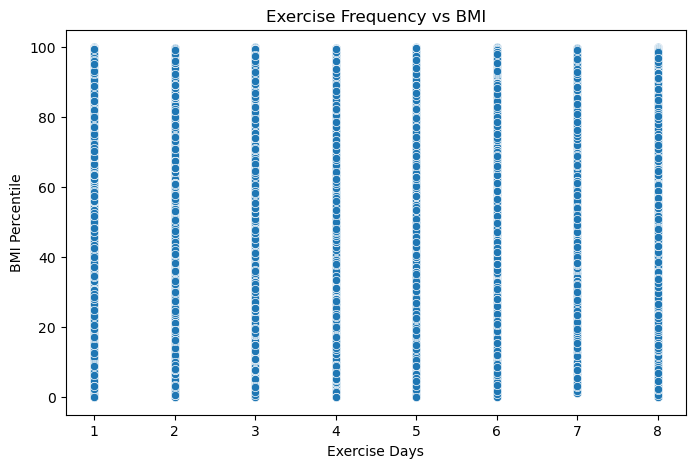

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='ExerciseDays',
    y='BMI',
    data=data
)

plt.title('Exercise Frequency vs BMI')
plt.xlabel('Exercise Days')
plt.ylabel('BMI Percentile')

plt.show()

## Regression Plot

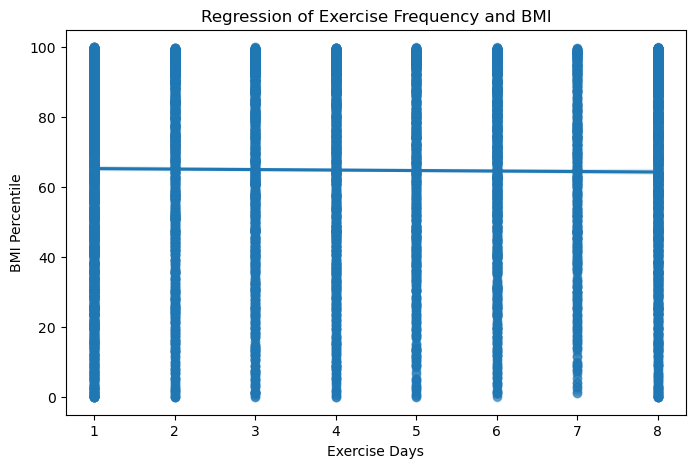

In [38]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='ExerciseDays',
    y='BMI',
    data=data,
    scatter_kws={'alpha':0.4}
)

plt.title('Regression of Exercise Frequency and BMI')
plt.xlabel('Exercise Days')
plt.ylabel('BMI Percentile')

plt.show()

In [39]:
X = data['ExerciseDays']
Y = data['BMI']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.176
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.140
Time:                        22:44:55   Log-Likelihood:                -61023.
No. Observations:               12894   AIC:                         1.221e+05
Df Residuals:                   12892   BIC:                         1.221e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           65.4206      0.454    144.023   

## Interpretation

The regression coefficient for ExerciseDays was -0.1393.

This indicates that BMI tends to decrease slightly as exercise frequency increases.

However, the relationship was not statistically significant (p = 0.140).

Therefore, we fail to reject the null hypothesis and conclude that exercise frequency does not significantly affect BMI among high school students.